# Day 08. Exercise 01
# Binary classifier. SVM. Decision tree

## 0. Imports

In [199]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.inspection import DecisionBoundaryDisplay

## 1. Preprocessing and logreg visualization

Read the file `am_pm.csv` to a dataframe from the previous exercise.

1. Draw a plot where the x-axis is `am`, the y-axis is `pm`, dots are the days, color depends on the target.
2. Add the decision boundary of logistic regression to the plot.
3. Draw the same plot (with the boundary), but the color should depend this time on the predictions.

Now it should be clear for you how the logistic regression works.

In [200]:
df = pd.read_csv('../data/am_pm.csv')
df['date'] = pd.to_datetime(df['date'])


In [201]:

X = df[['am', 'pm']]
y = df['target'].map({'weekend': 1, 'working_day': 0})


In [202]:

def plot_decision_boundary(model, X, y, title, ax=None):
    if ax is None:
        ax = plt.gca()
    
    x_min, x_max = X.iloc[:, 0].min() - 1, X.iloc[:, 0].max() + 1
    y_min, y_max = X.iloc[:, 1].min() - 1, X.iloc[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    
    colors = ['blue' if label == 0 else 'red' for label in y]
    ax.scatter(X.iloc[:, 0], X.iloc[:, 1], c=colors, edgecolors='k')
    
    ax.set_xlabel('AM Commits')
    ax.set_ylabel('PM Commits')
    ax.set_title(title)
    plt.grid(True)


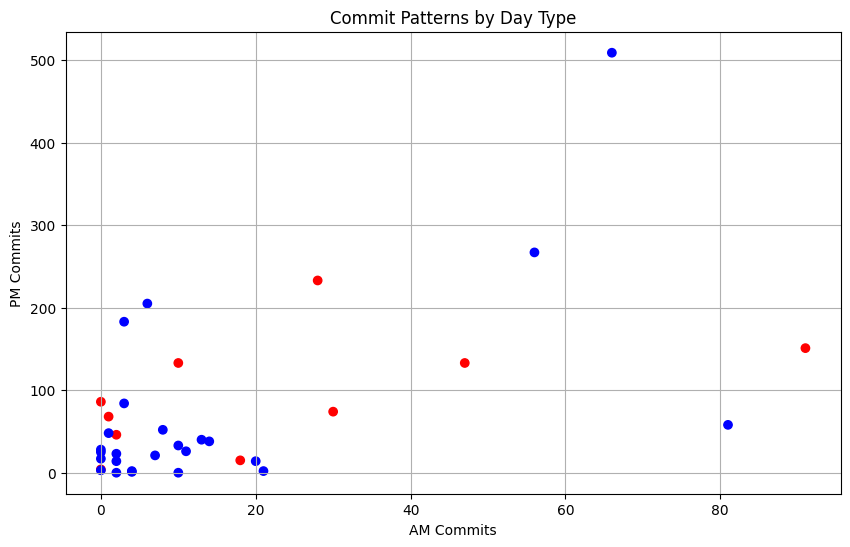

In [203]:

plt.figure(figsize=(10, 6))
colors = df['target'].map({'weekend': 'red', 'working_day': 'blue'})
plt.scatter(df['am'], df['pm'], c=colors)
plt.xlabel('AM Commits')
plt.ylabel('PM Commits')
plt.title('Commit Patterns by Day Type')
plt.grid(True)
plt.show()


In [204]:

lr = LogisticRegression(random_state=21, fit_intercept=False)
lr.fit(X, y)


LogisticRegression(fit_intercept=False, random_state=21)

/home/zelenn/.local/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


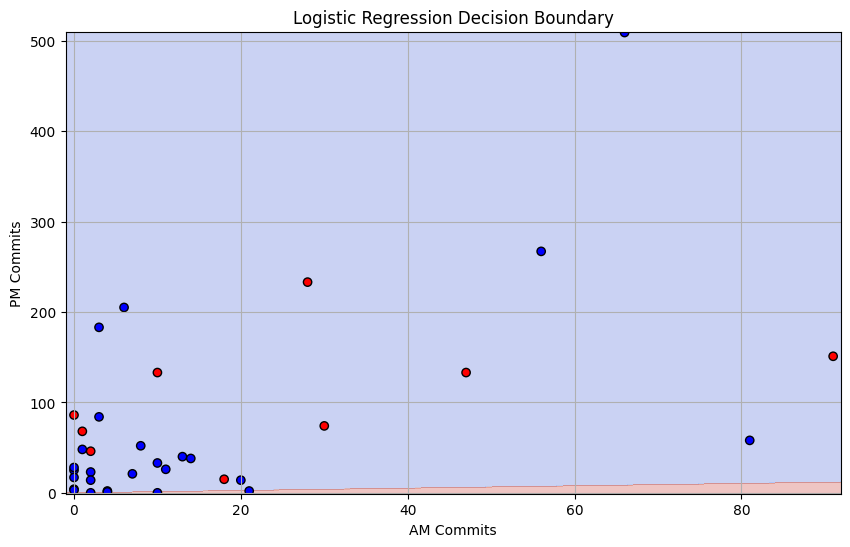

In [205]:

plt.figure(figsize=(10, 6))
plot_decision_boundary(lr, X, y, 'Logistic Regression Decision Boundary')
plt.show()


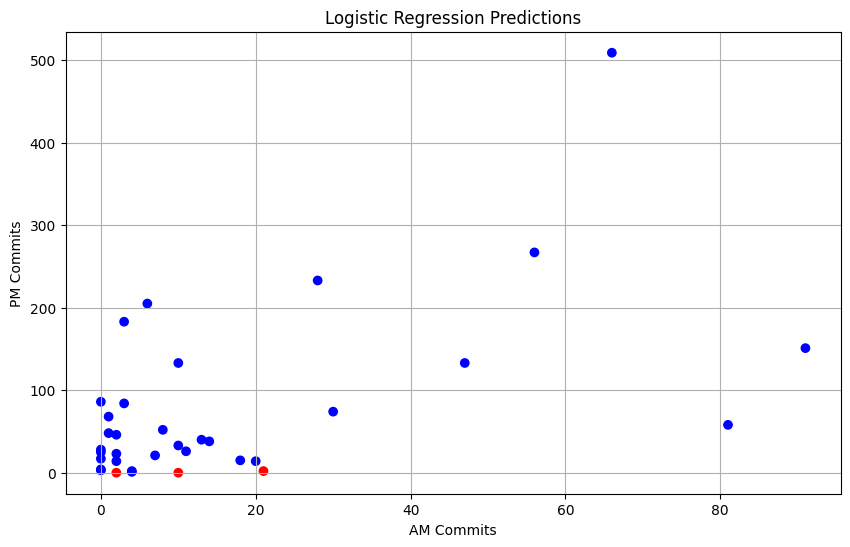

In [206]:

df['predict'] = lr.predict(X)
plt.figure(figsize=(10, 6))
colors_pred = ['blue' if p == 0 else 'red' for p in df['predict']]
plt.scatter(df['am'], df['pm'], c=colors_pred)
plt.xlabel('AM Commits')
plt.ylabel('PM Commits')
plt.title('Logistic Regression Predictions')
plt.grid(True)
plt.show()


## 2. Standardizing and logreg

Linear models can be sensitive to the scale of your variables. You make it easier for them to find the optimal solution when you scale your features.

1. Apply `StandardScaler` to `X` and train logistic regression again with the same parameters.


In [207]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=['am', 'pm'])


In [208]:

lr_scaled = LogisticRegression(random_state=21, fit_intercept=False)
lr_scaled.fit(X_scaled_df, y)


LogisticRegression(fit_intercept=False, random_state=21)

2. Calculate `accuracy` for the new model. Did it get better than a naive classifier with the most popular class?


In [209]:

accuracy = accuracy_score(y, lr_scaled.predict(X_scaled_df))
baseline_accuracy = max(y.value_counts(normalize=True))
print(f'Logistic Regression Accuracy (scaled): {accuracy:.2f}')
print(f'Baseline Accuracy: {baseline_accuracy:.2f}')


Logistic Regression Accuracy (scaled): 0.74
Baseline Accuracy: 0.71


3. Draw the plots that were described above but for the new model.

/home/zelenn/.local/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


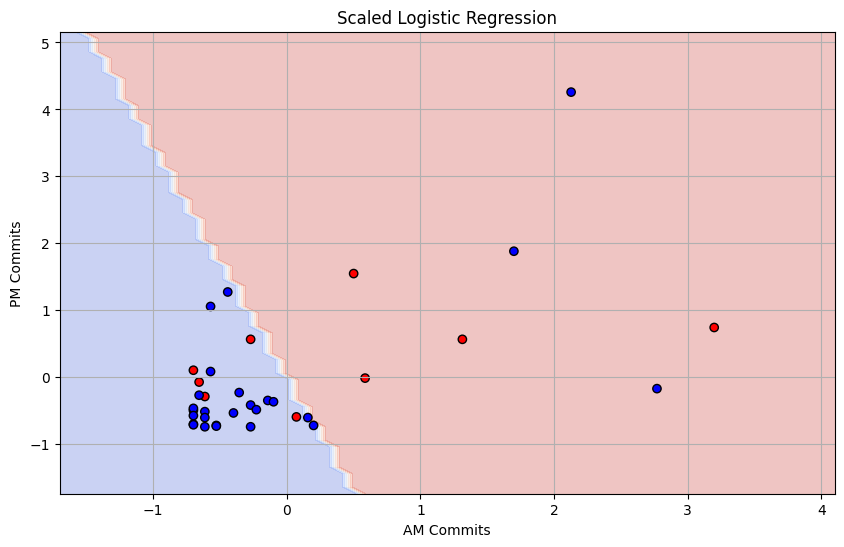

In [210]:

plt.figure(figsize=(10, 6))
plot_decision_boundary(lr_scaled, X_scaled_df, y, 'Scaled Logistic Regression')
plt.show()


## 3. SVM

1. Apply `SVC` model to the scaled dataframe using parameters `probability=True`, `random_state=21`.
2. Calculate `accuracy`.
3. Try different kernels, find the best in terms of accuracy.
4. Draw both plots again with the decisions boundary to see how this algorithm works.

In [211]:
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
best_accuracy = 0
best_svm = None

for kernel in kernels:
    svm = SVC(kernel=kernel, probability=True, random_state=21)
    svm.fit(X_scaled_df, y)
    acc = accuracy_score(y, svm.predict(X_scaled_df))
    print(f'SVM with {kernel} kernel: Accuracy = {acc:.2f}')
    
    if acc > best_accuracy:
        best_accuracy = acc
        best_svm = svm


SVM with linear kernel: Accuracy = 0.71
SVM with poly kernel: Accuracy = 0.74
SVM with rbf kernel: Accuracy = 0.74
SVM with sigmoid kernel: Accuracy = 0.69


/home/zelenn/.local/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


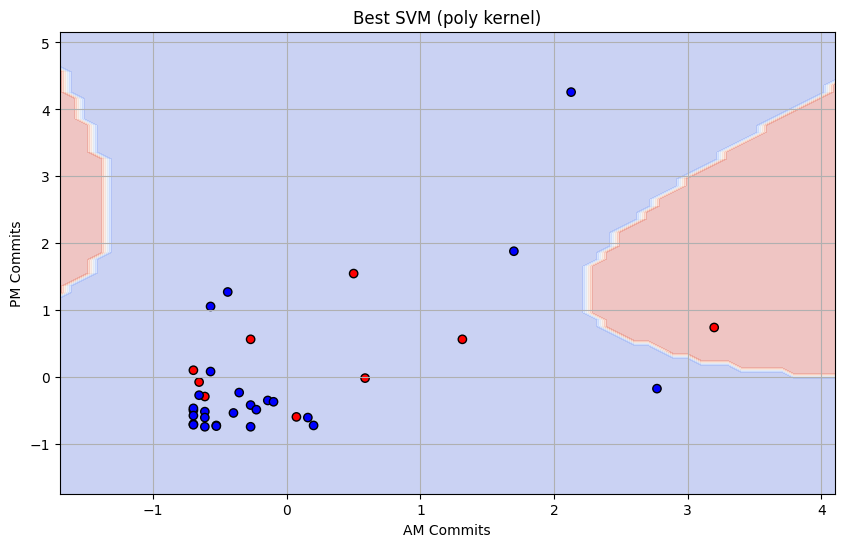

In [212]:
plt.figure(figsize=(10, 6))
plot_decision_boundary(best_svm, X_scaled_df, y, f'Best SVM ({best_svm.kernel} kernel)')
plt.show()

## 4. Decision tree

1. Apply `DecisionTreeClassifier` to the scaled dataframe using parameters `max_depth=4`, `random_state=42`.


In [213]:
dt = DecisionTreeClassifier(
    max_depth=4,
    random_state=42,
    splitter='best'
)
dt.fit(X_scaled_df, y)


DecisionTreeClassifier(max_depth=4, random_state=42)

2. Calculate accuracy.


In [214]:

acc = accuracy_score(y, dt.predict(X_scaled_df))
print(f'Decision Tree (max_depth=4): Accuracy = {acc:.4f}')


Decision Tree (max_depth=4): Accuracy = 0.9429


3. Try different values of `max_depth`.


In [215]:

print("\nTesting different depths:")
for depth in [2, 3, 4, 5, 6]:
    dt_test = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt_test.fit(X_scaled_df, y)
    acc = accuracy_score(y, dt_test.predict(X_scaled_df))
    print(f'Decision Tree (max_depth={depth}): Accuracy = {acc:.4f}')



Testing different depths:
Decision Tree (max_depth=2): Accuracy = 0.8571
Decision Tree (max_depth=3): Accuracy = 0.8857


Decision Tree (max_depth=4): Accuracy = 0.9429
Decision Tree (max_depth=5): Accuracy = 0.9714
Decision Tree (max_depth=6): Accuracy = 1.0000


4. Draw both plots again with the decisions boundary to see how this algorithm works.


/home/zelenn/.local/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


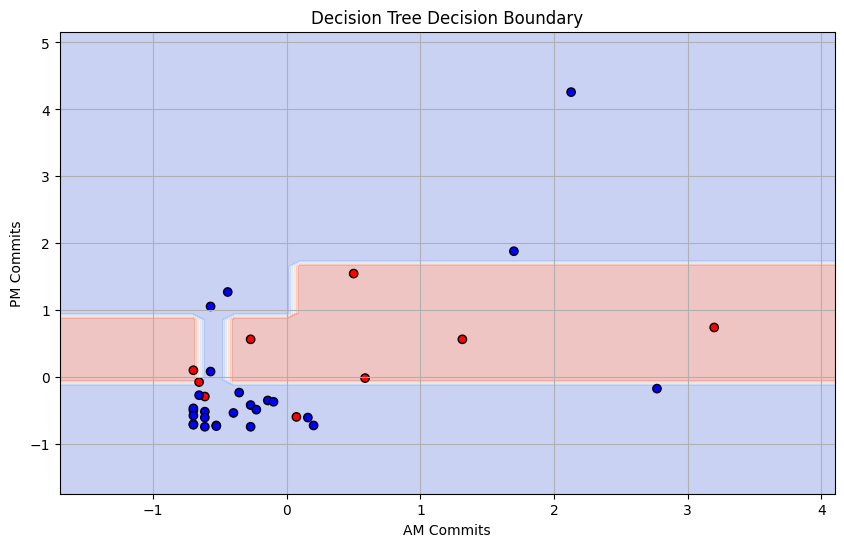

In [216]:

plt.figure(figsize=(10, 6))
plot_decision_boundary(dt, X_scaled_df, y, 'Decision Tree Decision Boundary')
plt.show()


5. Using method `.plot_tree()` visualize the decision tree itself. It is another way of thinking about how the algorithm works.


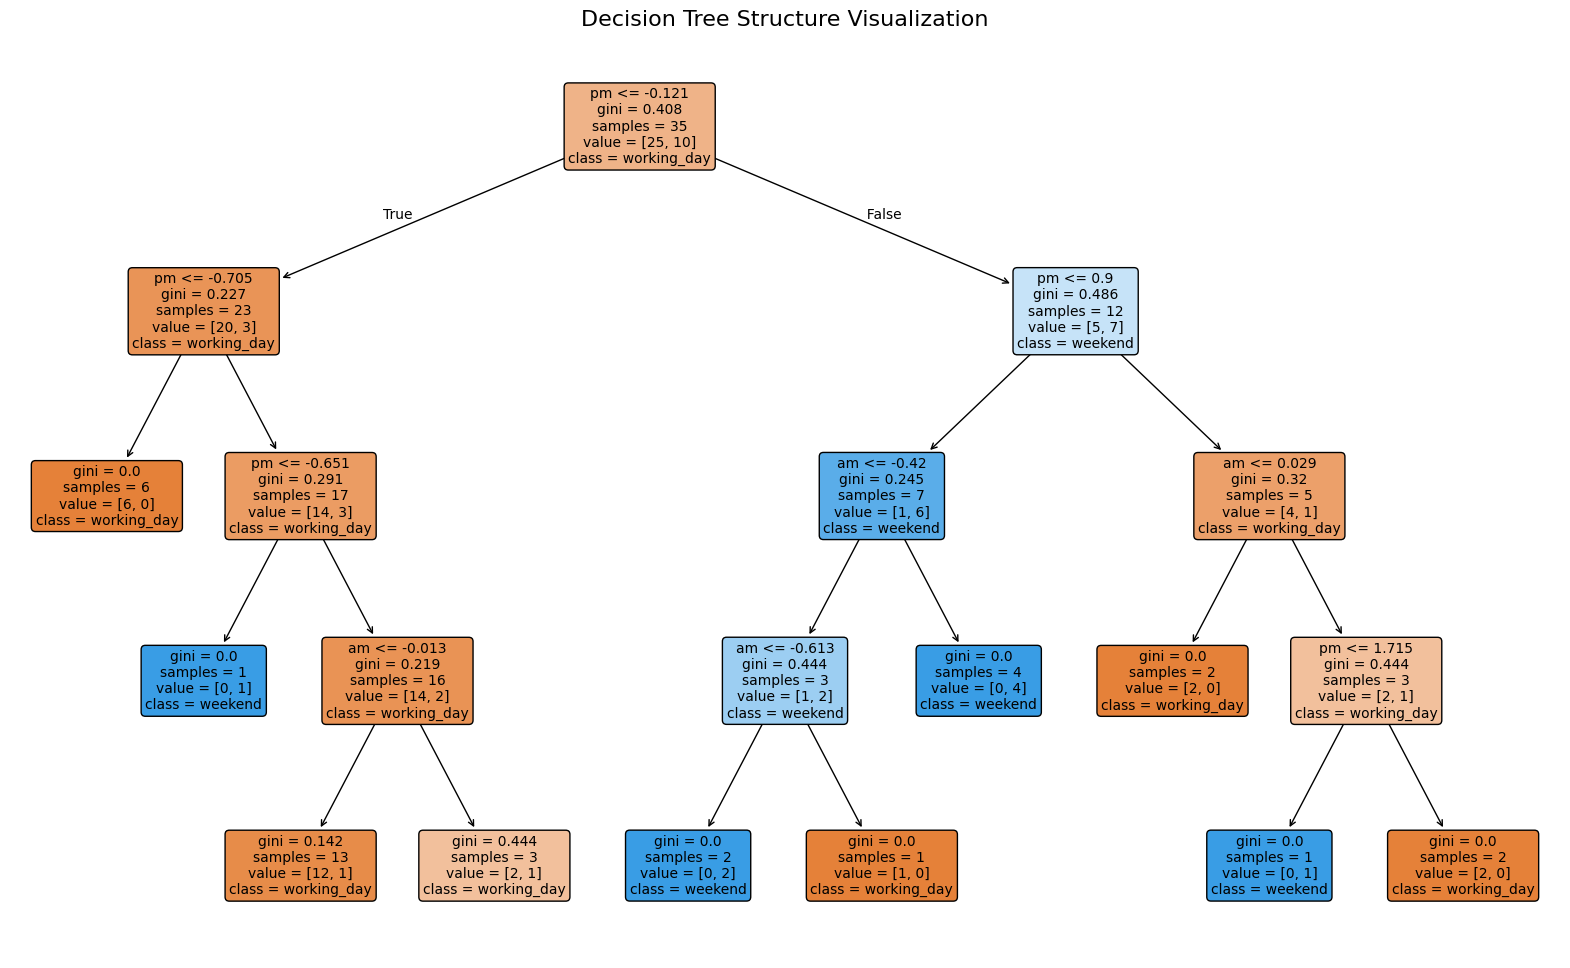

In [217]:

plt.figure(figsize=(20, 12))
plot_tree(dt, 
          feature_names=X_scaled_df.columns, 
          class_names=['working_day', 'weekend'], 
          filled=True, 
          rounded=True, 
          fontsize=10)
plt.title('Decision Tree Structure Visualization', fontsize=16)
plt.show()


6. How many leaves in the visualized tree label days as working days? Put your answer in the markdown cell in the end of the section.

In [218]:

def analyze_tree_leaves(tree, class_names):
    total_leaves = 0
    working_day_leaves = 0
    pure_working_day_leaves = 0
    leaf_details = []
    
    for i in range(tree.node_count):
        if tree.children_left[i] == -1 and tree.children_right[i] == -1:
            total_leaves += 1
            class_index = np.argmax(tree.value[i][0])
            class_name = class_names[class_index]
            gini = tree.impurity[i]
            samples = tree.n_node_samples[i]
            
            leaf_details.append({
                'node_id': i,
                'class': class_name,
                'gini': gini,
                'samples': samples,
                'is_pure': gini == 0.0
            })
            
            if class_name == 'working_day':
                working_day_leaves += 1
                if gini == 0.0:
                    pure_working_day_leaves += 1
    
    return total_leaves, working_day_leaves, pure_working_day_leaves, leaf_details

total_leaves, working_day_leaves, pure_working_day_leaves, leaf_details = analyze_tree_leaves(
    dt.tree_, ['working_day', 'weekend']
)

print(f"Total leaves: {total_leaves}")
print(f"Leaves labeling 'working_day': {working_day_leaves}")
print(f"Pure leaves (gini=0) for 'working_day': {pure_working_day_leaves}")

print("\nLeaf details:")
for leaf in leaf_details:
    purity = "PURE" if leaf['is_pure'] else "mixed"
    print(f"Node {leaf['node_id']}: Class={leaf['class']}, "
          f"Samples={leaf['samples']}, Gini={leaf['gini']:.4f} → {purity}")

Total leaves: 10
Leaves labeling 'working_day': 6
Pure leaves (gini=0) for 'working_day': 4

Leaf details:
Node 2: Class=working_day, Samples=6, Gini=0.0000 → PURE
Node 4: Class=weekend, Samples=1, Gini=0.0000 → PURE
Node 6: Class=working_day, Samples=13, Gini=0.1420 → mixed
Node 7: Class=working_day, Samples=3, Gini=0.4444 → mixed
Node 11: Class=weekend, Samples=2, Gini=0.0000 → PURE
Node 12: Class=working_day, Samples=1, Gini=0.0000 → PURE
Node 13: Class=weekend, Samples=4, Gini=0.0000 → PURE
Node 15: Class=working_day, Samples=2, Gini=0.0000 → PURE
Node 17: Class=weekend, Samples=1, Gini=0.0000 → PURE
Node 18: Class=working_day, Samples=2, Gini=0.0000 → PURE


Number of leaves labeling days as working days: 6, and 4 of them are pure